# Exploratory Data Analysis - Phase 3

In [1]:
# Load Processed Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv("data/processed/train_2010_2022.csv")
test_df = pd.read_csv("data/processed/test_2023_2025.csv")
predict_2026_df = pd.read_csv("data/processed/predict_2026.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Predict 2026:", predict_2026_df.shape)

Train: (120, 17)
Test: (34, 17)
Predict 2026: (10, 17)


In [2]:
# Combine Train and Test for EDA

eda_df = pd.concat([train_df, test_df], axis=0)

print("EDA Dataset:", eda_df.shape)
eda_df.head()

EDA Dataset: (154, 17)


,player_id,player_name,season,position,nfl_team,draft_round,draft_pick_overall,age_on_draft_day,height_inches,weight_lbs,college,college_games_played,career_yards,career_touchdowns,rookie_total_ppr_points,season_positional_finish,fantasy_relevant_binary
0,qb_2010_bradford,Sam Bradford,2010,QB,Rams,1,1,22,76,224,Oklahoma,31,8403,88,245.7,16.0,0.0
1,rb_2010_spiller,C.J. Spiller,2010,RB,Bills,1,9,23,71,194,Clemson,52,3547,32,95.2,49.0,0.0
2,rb_2010_mathews,Ryan Mathews,2010,RB,Chargers,1,12,22,72,220,Fresno St.,31,3280,39,158.3,32.0,0.0
3,te_2010_gresham,Jermaine Gresham,2010,TE,Bengals,1,21,22,77,260,Oklahoma,41,1629,26,112.1,16.0,0.0
4,wr_2010_thomas,Demaryius Thomas,2010,WR,Broncos,1,22,22,75,225,Georgia Tech,39,2339,15,52.3,87.0,0.0


In [3]:
# Check Seasons

eda_df["season"].value_counts().sort_index()

season
2010     8
2011     8
2012    11
2013     5
2014     9
2015    10
2016     8
2017    11
2018    11
2019     8
2020    11
2021    13
2022     7
2023    10
2024    14
2025    10
Name: count, dtype: int64

In [4]:
# Check Positions

eda_df["position"].value_counts()

position
WR    66
QB    51
RB    23
TE    14
Name: count, dtype: int64

In [5]:
# Summary of Numeric Columns

eda_df.describe()

,season,draft_round,draft_pick_overall,age_on_draft_day,height_inches,weight_lbs,college_games_played,career_yards,career_touchdowns,rookie_total_ppr_points,season_positional_finish,fantasy_relevant_binary
count,154.000000,154.0,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,2017.980519,1.0,14.376623,21.870130,73.707792,215.441558,37.785714,4521.603896,39.441558,173.757792,72.811688,0.409091
std,4.592507,0.0,9.803346,0.994766,2.556359,19.328595,8.600018,3279.452974,26.484917,97.296186,190.321083,0.493270
min,2010.000000,1.0,1.000000,20.000000,67.000000,165.000000,12.000000,778.000000,3.000000,0.000000,1.000000,0.000000
25%,2014.000000,1.0,6.000000,21.000000,72.000000,204.250000,32.000000,2316.250000,19.000000,94.975000,15.000000,0.000000
50%,2018.000000,1.0,12.000000,22.000000,74.000000,217.000000,38.000000,3156.000000,30.000000,179.800000,25.000000,0.000000
75%,2022.000000,1.0,23.000000,22.000000,76.000000,226.750000,41.750000,6201.000000,52.750000,242.550000,46.000000,1.000000
max,2025.000000,1.0,32.000000,28.000000,79.000000,260.000000,61.000000,15351.000000,131.000000,395.100000,999.000000,1.000000


In [6]:
# Check Target Distribution

eda_df["rookie_total_ppr_points"].describe()

count    154.000000
mean     173.757792
std       97.296186
min        0.000000
25%       94.975000
50%      179.800000
75%      242.550000
max      395.100000
Name: rookie_total_ppr_points, dtype: float64

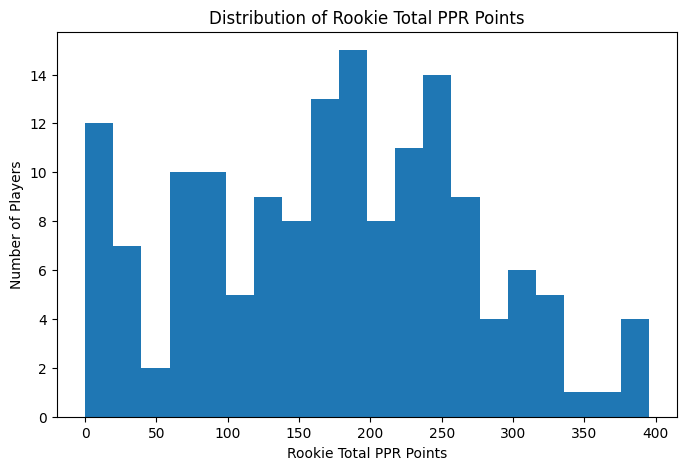

In [7]:
# Plot Target Distribution

plt.figure(figsize=(8, 5))
plt.hist(eda_df["rookie_total_ppr_points"].dropna(), bins=20)
plt.xlabel("Rookie Total PPR Points")
plt.ylabel("Number of Players")
plt.title("Distribution of Rookie Total PPR Points")
plt.show()

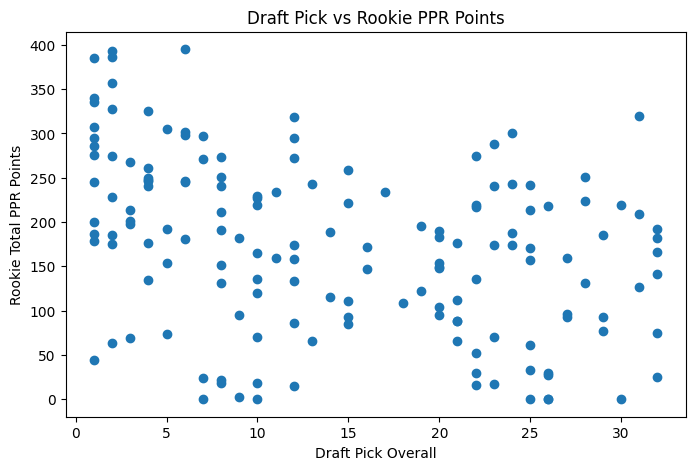

In [8]:
# Draft Pick vs Fantasy Points

plt.figure(figsize=(8, 5))
plt.scatter(
    eda_df["draft_pick_overall"],
    eda_df["rookie_total_ppr_points"]
)

plt.xlabel("Draft Pick Overall")
plt.ylabel("Rookie Total PPR Points")
plt.title("Draft Pick vs Rookie PPR Points")
plt.show()

In [9]:
# Average Fantasy Points by Position

eda_df.groupby("position")["rookie_total_ppr_points"].mean().sort_values(ascending=False)

position
RB    207.386957
QB    195.664706
WR    153.484848
TE    134.278571
Name: rookie_total_ppr_points, dtype: float64

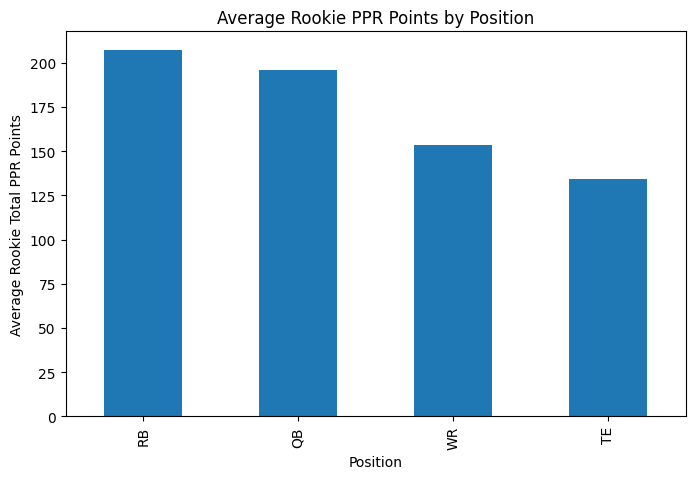

In [10]:
# Plot - Average Fantasy Points by Position

position_avg = eda_df.groupby("position")["rookie_total_ppr_points"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
position_avg.plot(kind="bar")
plt.xlabel("Position")
plt.ylabel("Average Rookie Total PPR Points")
plt.title("Average Rookie PPR Points by Position")
plt.show()

In [11]:
# Fantasy Relevant Count

eda_df["fantasy_relevant_binary"].value_counts()

fantasy_relevant_binary
0.0    91
1.0    63
Name: count, dtype: int64

In [12]:
# Fantasy Relevant Count (Normalized)

eda_df["fantasy_relevant_binary"].value_counts(normalize=True)

fantasy_relevant_binary
0.0    0.590909
1.0    0.409091
Name: proportion, dtype: float64

In [13]:
# Check for duplicate column names
eda_df = eda_df.reset_index(drop=True)

In [ ]:
# Chart - Fantasy Relevance by Position

relevance_by_position = pd.crosstab(
    eda_df["position"],
    eda_df["fantasy_relevant_binary"],
    normalize="index"
) * 100

relevance_by_position.round(1)

fantasy_relevant_binary,0.0,1.0
position,,
QB,84.3,15.7
RB,34.8,65.2
TE,42.9,57.1
WR,51.5,48.5
